In [2]:
import pandas as pd


In [3]:
df=pd.read_csv(r"C:\Users\ajkal\Downloads\weatherHistory.csv.zip")
df.shape

(96453, 12)

In [4]:
df.head(5)

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [5]:
df=df.drop(["Formatted Date","Summary","Daily Summary","Temperature (C)","Apparent Temperature (C)"],axis=1)

In [6]:
df

,Precip Type,Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
0,rain,0.89,14.1197,251.0,15.8263,0.0,1015.13
1,rain,0.86,14.2646,259.0,15.8263,0.0,1015.63
2,rain,0.89,3.9284,204.0,14.9569,0.0,1015.94
3,rain,0.83,14.1036,269.0,15.8263,0.0,1016.41
4,rain,0.83,11.0446,259.0,15.8263,0.0,1016.51
...,...,...,...,...,...,...,...
96448,rain,0.43,10.9963,31.0,16.1000,0.0,1014.36
96449,rain,0.48,10.0947,20.0,15.5526,0.0,1015.16
96450,rain,0.56,8.9838,30.0,16.1000,0.0,1015.66
96451,rain,0.60,10.5294,20.0,16.1000,0.0,1015.95


In [7]:
df["Precip Type"]=df["Precip Type"].replace({"rain":1,"snow":2})

C:\Users\ajkal\AppData\Local\Temp\ipykernel_16976\1982846906.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Precip Type"]=df["Precip Type"].replace({"rain":1,"snow":2})


In [8]:
df

,Precip Type,Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
0,1.0,0.89,14.1197,251.0,15.8263,0.0,1015.13
1,1.0,0.86,14.2646,259.0,15.8263,0.0,1015.63
2,1.0,0.89,3.9284,204.0,14.9569,0.0,1015.94
3,1.0,0.83,14.1036,269.0,15.8263,0.0,1016.41
4,1.0,0.83,11.0446,259.0,15.8263,0.0,1016.51
...,...,...,...,...,...,...,...
96448,1.0,0.43,10.9963,31.0,16.1000,0.0,1014.36
96449,1.0,0.48,10.0947,20.0,15.5526,0.0,1015.16
96450,1.0,0.56,8.9838,30.0,16.1000,0.0,1015.66
96451,1.0,0.60,10.5294,20.0,16.1000,0.0,1015.95


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Precip Type             95936 non-null  float64
 1   Humidity                96453 non-null  float64
 2   Wind Speed (km/h)       96453 non-null  float64
 3   Wind Bearing (degrees)  96453 non-null  float64
 4   Visibility (km)         96453 non-null  float64
 5   Loud Cover              96453 non-null  float64
 6   Pressure (millibars)    96453 non-null  float64
dtypes: float64(7)
memory usage: 5.2 MB


In [10]:
df["Precip Type"].fillna(df["Precip Type"].mode()[0],inplace=True)


C:\Users\ajkal\AppData\Local\Temp\ipykernel_16976\58500757.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Precip Type"].fillna(df["Precip Type"].mode()[0],inplace=True)


In [11]:
x=df.drop(["Precip Type"],axis=1)
y=df["Precip Type"]


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [13]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [14]:

model_log=LogisticRegression()

In [15]:
model_log.fit(x_train,y_train)

LogisticRegression()

In [16]:
pred=model_log.predict(x_test)
acc=accuracy_score(y_test,pred)
print(acc)

0.8848167539267016


In [17]:
from sklearn.neighbors import KNeighborsClassifier

In [18]:
model_kn=KNeighborsClassifier(n_neighbors=10)
model_kn.fit(x_train,y_train)
kn_pred=model_kn.predict(x_test)
acc=accuracy_score(y_test,kn_pred)
print(acc)

0.8975169768285729


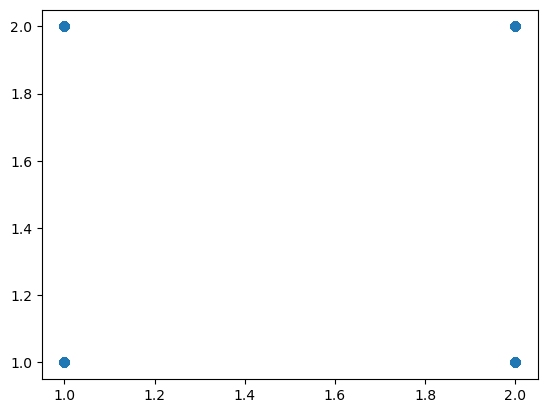

In [19]:
import matplotlib.pyplot as plt
plt.scatter(y_test,kn_pred)
plt.show()

In [20]:
import pickle
with open("model.pkl","wb") as file:
    pickle.dump(model_kn,file)